In [30]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [36]:
DATA_PATH = '../data/raw/'

print('Dataset path set successfully!')
print('Dataset Path:', DATA_PATH)

Dataset path set successfully!
Dataset Path: ../data/raw/


In [37]:
files = sorted(os.listdir(DATA_PATH))

print('='*70)
print('AVAILABLE DATASET FILES')
print('='*70)

for idx, file in enumerate(files, start=1):
    print(f'{idx}. {file}')

AVAILABLE DATASET FILES
1. X_2018clinical.npy
2. X_2019clinical.npy
3. X_finetune.npy
4. X_reference.npy
5. X_test.npy
6. wavenumbers.npy
7. y_2018clinical.npy
8. y_2019clinical.npy
9. y_finetune.npy
10. y_reference.npy
11. y_test.npy


In [38]:
X_reference = np.load(DATA_PATH + 'X_reference.npy')
y_reference = np.load(DATA_PATH + 'y_reference.npy')

X_finetune = np.load(DATA_PATH + 'X_finetune.npy')
y_finetune = np.load(DATA_PATH + 'y_finetune.npy')

X_test = np.load(DATA_PATH + 'X_test.npy')
y_test = np.load(DATA_PATH + 'y_test.npy')

X_2018 = np.load(DATA_PATH + 'X_2018clinical.npy')
y_2018 = np.load(DATA_PATH + 'y_2018clinical.npy')

X_2019 = np.load(DATA_PATH + 'X_2019clinical.npy')
y_2019 = np.load(DATA_PATH + 'y_2019clinical.npy')

wavenumbers = np.load(DATA_PATH + 'wavenumbers.npy')

print('All dataset files loaded successfully!')

All dataset files loaded successfully!


In [39]:
summary = {
    'File Name': [
        'X_reference.npy',
        'y_reference.npy',
        'X_finetune.npy',
        'y_finetune.npy',
        'X_test.npy',
        'y_test.npy',
        'X_2018clinical.npy',
        'y_2018clinical.npy',
        'X_2019clinical.npy',
        'y_2019clinical.npy',
        'wavenumbers.npy'
    ],

    'Purpose': [
        'Reference spectra',
        'Reference labels',
        'Fine-tuning spectra',
        'Fine-tuning labels',
        'Reference test spectra',
        'Reference test labels',
        'Clinical spectra (2018)',
        'Clinical labels (2018)',
        'Clinical spectra (2019)',
        'Clinical labels (2019)',
        'Raman shift values'
    ],

    'Shape': [
        X_reference.shape,
        y_reference.shape,
        X_finetune.shape,
        y_finetune.shape,
        X_test.shape,
        y_test.shape,
        X_2018.shape,
        y_2018.shape,
        X_2019.shape,
        y_2019.shape,
        wavenumbers.shape
    ],

    'Datatype': [
        X_reference.dtype,
        y_reference.dtype,
        X_finetune.dtype,
        y_finetune.dtype,
        X_test.dtype,
        y_test.dtype,
        X_2018.dtype,
        y_2018.dtype,
        X_2019.dtype,
        y_2019.dtype,
        wavenumbers.dtype
    ]
}

summary_df = pd.DataFrame(summary)

print('='*100)
print('DATASET FILE STRUCTURE SUMMARY')
print('='*100)

summary_df

DATASET FILE STRUCTURE SUMMARY


,File Name,Purpose,Shape,Datatype
0,X_reference.npy,Reference spectra,"(60000, 1000)",float64
1,y_reference.npy,Reference labels,"(60000,)",float64
2,X_finetune.npy,Fine-tuning spectra,"(3000, 1000)",float64
3,y_finetune.npy,Fine-tuning labels,"(3000,)",float64
4,X_test.npy,Reference test spectra,"(3000, 1000)",float64
5,y_test.npy,Reference test labels,"(3000,)",float64
6,X_2018clinical.npy,Clinical spectra (2018),"(10000, 1000)",float64
7,y_2018clinical.npy,Clinical labels (2018),"(10000,)",float64
8,X_2019clinical.npy,Clinical spectra (2019),"(2500, 1000)",float64
9,y_2019clinical.npy,Clinical labels (2019),"(2500,)",float64


In [44]:
print('='*70)
print('REFERENCE DATASET EXPLORATION')
print('='*70)

print(f'Total spectra        : {X_reference.shape[0]}')
print(f'Spectral dimensions  : {X_reference.shape[1]}')

print('Unique Classes:')
print(np.unique(y_reference))

print('Total Classes:', len(np.unique(y_reference)))

REFERENCE DATASET EXPLORATION
Total spectra        : 60000
Spectral dimensions  : 1000
Unique Classes:
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29.]
Total Classes: 30


In [45]:
ref_counts = Counter(y_reference)

ref_df = pd.DataFrame({
    'Class Label': list(ref_counts.keys()),
    'Number of Spectra': list(ref_counts.values())
})

ref_df = ref_df.sort_values('Class Label')

print('='*70)
print('REFERENCE DATASET CLASS DISTRIBUTION')
print('='*70)

ref_df

REFERENCE DATASET CLASS DISTRIBUTION


,Class Label,Number of Spectra
0,0.0,2000
1,1.0,2000
2,2.0,2000
3,3.0,2000
4,4.0,2000
5,5.0,2000
6,6.0,2000
7,7.0,2000
8,8.0,2000
9,9.0,2000


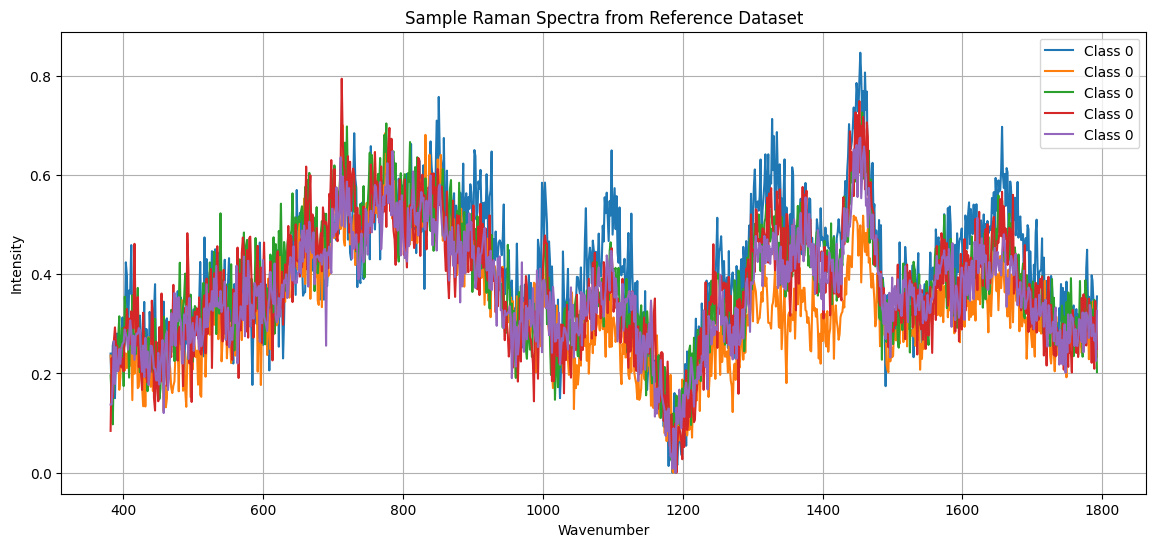

In [46]:
plt.figure(figsize=(14,6))

for i in range(5):
    plt.plot(wavenumbers,
             X_reference[i],
             label=f'Class {int(y_reference[i])}')

plt.xlabel('Wavenumber')
plt.ylabel('Intensity')
plt.title('Sample Raman Spectra from Reference Dataset')
plt.legend()
plt.grid(True)
plt.show()

In [48]:
print('='*70)
print('FINE-TUNING DATASET')
print('='*70)

print(f'Total spectra       : {X_finetune.shape[0]}')
print(f'Spectral dimensions : {X_finetune.shape[1]}')

print('Unique classes:')
print(np.unique(y_finetune))

print('Total Classes:', len(np.unique(y_finetune)))

FINE-TUNING DATASET
Total spectra       : 3000
Spectral dimensions : 1000
Unique classes:
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29.]
Total Classes: 30


In [50]:
print('='*70)
print('REFERENCE TEST DATASET')
print('='*70)

print(f'Total spectra       : {X_test.shape[0]}')
print(f'Spectral dimensions : {X_test.shape[1]}')

print('Unique classes:')
print(np.unique(y_test))

print('Total Classes:', len(np.unique(y_test)))

REFERENCE TEST DATASET
Total spectra       : 3000
Spectral dimensions : 1000
Unique classes:
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29.]
Total Classes: 30


In [22]:
print('Unique classes:')
print(np.unique(y_test))

print('Total classes:', len(np.unique(y_test)))

Unique classes:
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29.]
Total classes: 30


In [51]:
print('='*70)
print('CLINICAL DATASET 2018')
print('='*70)

print(f'Total spectra       : {X_2018.shape[0]}')
print(f'Spectral dimensions : {X_2018.shape[1]}')

print('\nUnique Labels:')
print(np.unique(y_2018))

print('\nTotal Treatment Groups:', len(np.unique(y_2018)))


print('\n' + '='*70)
print('CLINICAL DATASET 2019')
print('='*70)

print(f'Total spectra       : {X_2019.shape[0]}')
print(f'Spectral dimensions : {X_2019.shape[1]}')

print('\nUnique Labels:')
print(np.unique(y_2019))

print('\nTotal Treatment Groups:', len(np.unique(y_2019)))

CLINICAL DATASET 2018
Total spectra       : 10000
Spectral dimensions : 1000

Unique Labels:
[0. 2. 3. 5. 6.]

Total Treatment Groups: 5

CLINICAL DATASET 2019
Total spectra       : 2500
Spectral dimensions : 1000

Unique Labels:
[0. 2. 3. 5. 6.]

Total Treatment Groups: 5


In [52]:
comparison_df = pd.DataFrame({

    'Dataset': [
        'Reference',
        'Fine-tune',
        'Reference Test',
        'Clinical 2018',
        'Clinical 2019'
    ],

    'Purpose': [
        'Primary training',
        'Domain adaptation',
        'Reference evaluation',
        'Clinical adaptation',
        'Generalization testing'
    ],

    'Samples': [
        X_reference.shape[0],
        X_finetune.shape[0],
        X_test.shape[0],
        X_2018.shape[0],
        X_2019.shape[0]
    ],

    'Features per Spectrum': [
        X_reference.shape[1],
        X_finetune.shape[1],
        X_test.shape[1],
        X_2018.shape[1],
        X_2019.shape[1]
    ],

    'Number of Classes': [
        len(np.unique(y_reference)),
        len(np.unique(y_finetune)),
        len(np.unique(y_test)),
        len(np.unique(y_2018)),
        len(np.unique(y_2019))
    ]
})

print('='*100)
print('COMPLETE DATASET COMPARISON')
print('='*100)

comparison_df

COMPLETE DATASET COMPARISON


,Dataset,Purpose,Samples,Features per Spectrum,Number of Classes
0,Reference,Primary training,60000,1000,30
1,Fine-tune,Domain adaptation,3000,1000,30
2,Reference Test,Reference evaluation,3000,1000,30
3,Clinical 2018,Clinical adaptation,10000,1000,5
4,Clinical 2019,Generalization testing,2500,1000,5


In [53]:
print('='*70)
print('WAVENUMBER INFORMATION')
print('='*70)

print(f'Total wavenumber points : {len(wavenumbers)}')
print(f'Minimum wavenumber      : {wavenumbers.min()}')
print(f'Maximum wavenumber      : {wavenumbers.max()}')

print('\nFirst 20 wavenumber values:\n')
print(wavenumbers[:20])

WAVENUMBER INFORMATION
Total wavenumber points : 1000
Minimum wavenumber      : 381.98
Maximum wavenumber      : 1792.4

First 20 wavenumber values:

[1792.4 1791.2 1789.9 1788.6 1787.3 1786.  1784.8 1783.5 1782.2 1780.9
 1779.6 1778.3 1777.1 1775.8 1774.5 1773.2 1771.9 1770.6 1769.4 1768.1]


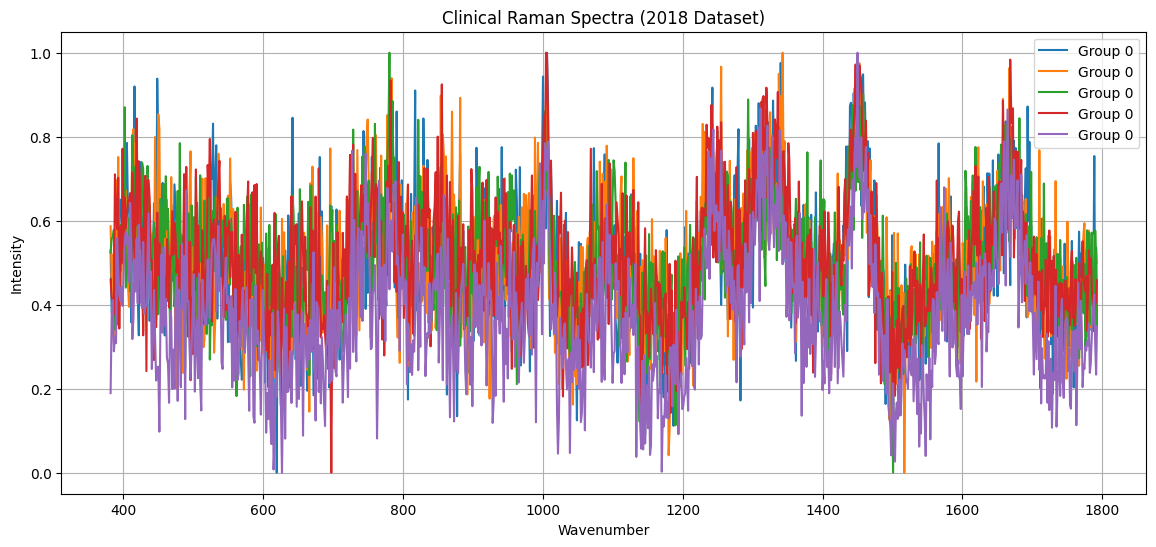

In [54]:
plt.figure(figsize=(14,6))

for i in range(5):
    plt.plot(
        wavenumbers,
        X_2018[i],
        label=f'Group {int(y_2018[i])}'
    )

plt.xlabel('Wavenumber')
plt.ylabel('Intensity')
plt.title('Clinical Raman Spectra (2018 Dataset)')
plt.legend()
plt.grid(True)

plt.show()